# Cuaderno de prueba para descarga de imágenes de GEE (SWISSIMAGE, 0.112 m/px)

Este notebook replica el flujo de la prueba anterior, pero sustituye PNOA por **SWISSIMAGE 10 cm** en Earth Engine.
El objetivo es obtener un recorte RGB con:

- **encuadre fijo de 115 m × 70 m**
- **exportación a `scale = 0.112` m/px (11.2 cm/px)**
- **salida en GeoTIFF + PNG + JPG**
- **dimensiones muy cercanas a las imágenes del artículo tras el downsampling ×8**


## 1. Preparación del entorno

Se instalan las librerías necesarias para autenticarse en Earth Engine, descargar el ráster y generar copias PNG/JPG.


In [1]:
!pip install -q earthengine-api requests rasterio matplotlib pillow


## 2. Autenticación e inicialización de Google Earth Engine

Inicializa Earth Engine con el proyecto de Google Cloud. Si la sesión no está autenticada, lanza el flujo interactivo.


In [2]:
import ee

PROJECT_ID = "golden-tide-482516-f7"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate(auth_mode="notebook")
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente")


Earth Engine inicializado correctamente


## 3. Importación de librerías

Se cargan las librerías que se usarán para descargar, leer, exportar y visualizar la imagen.


In [3]:
import requests
import rasterio
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


## 4. Selección automática de una zona rural en SWISSIMAGE

Se busca un punto rural dentro de la cobertura de **SWISSIMAGE 10 cm** usando:

- un punto semilla en una zona de valle alpino del ejemplo oficial
- la cobertura global **ESA WorldCover 2021**
- clases abiertas (`grassland` y `cropland`)
- exclusión de `built-up`
- preferencia por áreas homogéneas (más limpias visualmente)


In [ ]:
# Punto semilla dentro de la cobertura oficial de ejemplo de swissimage
seed_lon = 7.75
seed_lat = 46.02

# Radio moderado para no salir demasiado de la zona de valle
search_radius_m = 10000  # 10 km

# Parámetros del recorte final
paper_width_m = 115.0
paper_height_m = 70.0

# Resolución objetivo de salida: 11.2 cm/píxel
target_scale_m = 0.112

# UTM 32N para esa zona de Suiza
utm_crs = "EPSG:32632"

# Controla qué candidato elegir
candidate_rank = 7  # 0 = mejor candidato, 1 = siguiente, etc...

seed_point = ee.Geometry.Point([seed_lon, seed_lat])
search_area = seed_point.buffer(search_radius_m)

# Cobertura SWISSIMAGE en el área
swiss_local = ee.ImageCollection("Switzerland/SWISSIMAGE/orthos/10cm").filterBounds(search_area)

n_local = swiss_local.size().getInfo()
print("Teselas SWISSIMAGE en el área de búsqueda:", n_local)

if n_local == 0:
    raise ValueError("No hay cobertura SWISSIMAGE en esta zona de búsqueda.")

covered_region = swiss_local.geometry().intersection(search_area, 1)

# WorldCover 2021
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map")

# Clases:
# 30 = grassland
# 40 = cropland
# 50 = built-up
open_mask = worldcover.eq(30).Or(worldcover.eq(40))
built_mask = worldcover.eq(50)

# Excluir entorno próximo a urbano
built_buffer = built_mask.focal_max(radius=300, units="meters")

# Candidatos: zonas abiertas y lejos de urbano
candidate_mask = open_mask.And(built_buffer.Not()).rename("candidate")

# Homogeneidad local: zonas más limpias
open_fraction = (
    open_mask.unmask(0)
    .focal_mean(radius=200, units="meters")
    .rename("open_frac")
)

sample_img = open_fraction.updateMask(candidate_mask)

samples = sample_img.sample(
    region=covered_region,
    scale=10,
    numPixels=300,
    seed=42,
    geometries=True
)

n_samples = samples.size().getInfo()
print("Puntos rurales candidatos:", n_samples)

if n_samples == 0:
    raise ValueError("No se encontró un punto rural válido. Prueba subiendo search_radius_m o cambiando el seed.")

def add_scores(feat):
    dist = feat.geometry().distance(seed_point, 1)
    open_frac = ee.Number(feat.get("open_frac"))
    score = open_frac.multiply(1000000).add(dist)
    return feat.set({
        "dist_m": dist,
        "score": score
    })

ranked = samples.map(add_scores).sort("score", False)

top_n = ranked.size().getInfo()
use_rank = min(candidate_rank, max(0, top_n - 1))

chosen_feature = ee.Feature(ranked.toList(top_n).get(use_rank))
chosen_point = chosen_feature.geometry()

chosen_lon, chosen_lat = chosen_point.coordinates().getInfo()
chosen_dist = chosen_feature.get("dist_m").getInfo()
chosen_open = chosen_feature.get("open_frac").getInfo()

print("Punto elegido:")
print("lon =", chosen_lon)
print("lat =", chosen_lat)
print("Distancia al punto semilla (m):", round(chosen_dist, 1))
print("Fracción de zona abierta alrededor:", round(chosen_open, 3))
print("Ranking usado:", use_rank)


Teselas SWISSIMAGE en el área de búsqueda: 3
Puntos rurales candidatos: 40
Punto elegido:
lon = 7.749544514083179
lat = 46.04712640330455
Distancia al punto semilla (m): 3015.4
Fracción de zona abierta alrededor: 0.886
Ranking usado: 7


## 5. Construcción del AOI final (115 m × 70 m)

A partir del punto seleccionado, se construye un rectángulo exacto de **115 m de ancho** por **70 m de alto**.
Con `scale = 0.112`, la salida esperada es de aproximadamente:

- `115 / 0.112 ≈ 1027 px`
- `70 / 0.112 = 625 px`


In [5]:
chosen_point_utm = chosen_point.transform(utm_crs, 1)
x, y = chosen_point_utm.coordinates().getInfo()

aoi = ee.Geometry.Rectangle(
    [
        x - paper_width_m / 2,
        y - paper_height_m / 2,
        x + paper_width_m / 2,
        y + paper_height_m / 2
    ],
    proj=utm_crs,
    geodesic=False
)

print("AOI creada")
print("Ancho (m):", paper_width_m)
print("Alto (m):", paper_height_m)
print("Tamaño esperado a 0.112 m/px:", round(paper_width_m / target_scale_m), "x", round(paper_height_m / target_scale_m), "px")


AOI creada
Ancho (m): 115.0
Alto (m): 70.0
Tamaño esperado a 0.112 m/px: 1027 x 625 px


## 6. Obtención de la imagen SWISSIMAGE y generación de la URL de descarga

Se usa la ortofoto SWISSIMAGE 2020 (10 cm en llanuras y valles alpinos principales; 25 cm en Alpes) y se recorta sobre el AOI final.
La exportación se fuerza a `scale = 0.112`.


In [6]:
# Usamos explícitamente la versión 2020 para mantener el notebook estable y reproducible
image = (
    ee.Image("Switzerland/SWISSIMAGE/orthos/10cm/2020")
    .select(["R", "G", "B"])
    .clip(aoi)
)

url = image.getDownloadURL({
    "region": aoi,
    "scale": target_scale_m,   # 0.112 m/píxel = 11.2 cm/píxel
    "crs": utm_crs,
    "format": "GEO_TIFF",
    "filePerBand": False,
    "name": "swissimage_115x70_0112m_demo"
})

print("URL generada correctamente:")
print(url)


URL generada correctamente:
https://earthengine.googleapis.com/v1/projects/golden-tide-482516-f7/thumbnails/b19d9766d551a7adf8d73bbc1810263c-a77950e088e209be406195e0aee6dc66:getPixels


## 7. Descarga del GeoTIFF

Se descarga el archivo desde la URL temporal generada por Earth Engine y se guarda en disco.


In [7]:
out_tif = "swissimage_115x70_0112m_demo.tif"

r = requests.get(url, stream=True, timeout=120)
r.raise_for_status()

with open(out_tif, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print("Guardado:", out_tif)


Guardado: swissimage_115x70_0112m_demo.tif


## 8. Exportación de copias a TIFF, PNG y JPG

Se crea una carpeta `prueba4_output` y se guardan copias sin sobrescribir archivos previos.
Si ya existe un nombre, se añade ` (1)`, ` (2)`, etc.


In [8]:
def next_available_path(path: Path) -> Path:
    if not path.exists():
        return path

    stem = path.stem
    suffix = path.suffix
    parent = path.parent

    i = 1
    while True:
        candidate = parent / f"{stem} ({i}){suffix}"
        if not candidate.exists():
            return candidate
        i += 1

output_dir = Path("prueba4_output")
output_dir.mkdir(exist_ok=True)

src_tif = Path(out_tif)
if not src_tif.exists():
    raise FileNotFoundError(f"No existe el archivo TIFF: {src_tif}")

# 1) Copia del GeoTIFF sin sobrescribir
dst_tif = next_available_path(output_dir / src_tif.name)
shutil.copy2(src_tif, dst_tif)

# 2) Lectura del GeoTIFF para generar PNG/JPG
with rasterio.open(src_tif) as src:
    data = src.read([1, 2, 3]).astype(np.float32)
    nodata = src.nodata

rgb = np.moveaxis(data, 0, -1)

if nodata is not None:
    valid = np.any(rgb != nodata, axis=2)
else:
    valid = np.any(rgb != 0, axis=2)

if np.any(valid) and np.nanmax(rgb[valid]) <= 255:
    rgb_8 = np.clip(rgb, 0, 255).astype(np.uint8)
else:
    rgb_8 = np.zeros_like(rgb, dtype=np.uint8)
    for i in range(3):
        vals = rgb[..., i][valid]
        if len(vals) > 0:
            p2, p98 = np.percentile(vals, (2, 98))
            if p98 > p2:
                band_scaled = (rgb[..., i] - p2) / (p98 - p2)
                rgb_8[..., i] = np.clip(band_scaled * 255, 0, 255).astype(np.uint8)

rgb_8[~valid] = 255

img = Image.fromarray(rgb_8, mode="RGB")

png_path = next_available_path(output_dir / f"{src_tif.stem}.png")
jpg_path = next_available_path(output_dir / f"{src_tif.stem}.jpg")

img.save(png_path)
img.save(jpg_path, quality=95)

print("Archivos guardados en:", output_dir.resolve())
print("-", dst_tif.name)
print("-", png_path.name)
print("-", jpg_path.name)


Archivos guardados en: C:\Users\Usuario\OneDrive\Documentos\TFG-Algoritmo\Pruebas GEE\prueba4_output
- swissimage_115x70_0112m_demo (3).tif
- swissimage_115x70_0112m_demo (3).png
- swissimage_115x70_0112m_demo (3).jpg


## 9. Inspección de metadatos del ráster

Se comprueban dimensiones, CRS, NoData, extensión y tipo de dato del GeoTIFF.


In [9]:
with rasterio.open(out_tif) as src:
    print("Bandas:", src.count)
    print("Tamaño:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Tipo:", src.dtypes)


Bandas: 3
Tamaño: 1027 x 626
CRS: EPSG:32632
NoData: 0.0
Bounds: BoundingBox(left=403199.328, bottom=5100008.592, right=403314.35199999996, top=5100078.704)
Tipo: ('uint8', 'uint8', 'uint8')


## 10. Visualización rápida del resultado

Se muestra una vista rápida en el notebook para validar que el contenido es correcto y que el raster es interpretable.


Tamaño: 1027 x 626
CRS: EPSG:32632
NoData: 0.0
Tipo: ('uint8', 'uint8', 'uint8')


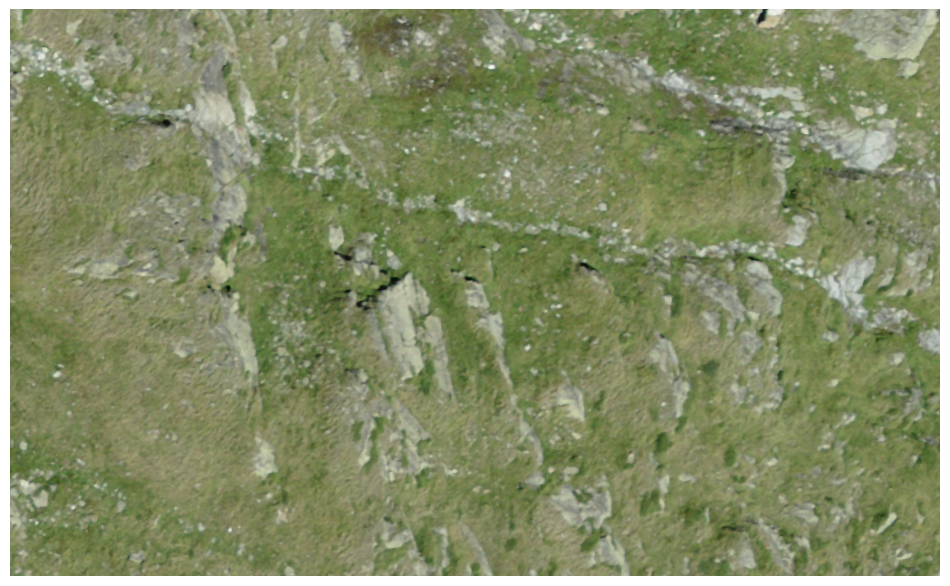

In [10]:
with rasterio.open(out_tif) as src:
    rgb = src.read([1, 2, 3]).astype(np.float32)
    nodata = src.nodata
    print("Tamaño:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Tipo:", src.dtypes)

rgb = np.moveaxis(rgb, 0, -1)

if nodata is not None:
    valid = np.any(rgb != nodata, axis=2)
else:
    valid = np.any(rgb != 0, axis=2)

if np.nanmax(rgb[valid]) <= 255:
    rgb_vis = rgb / 255.0
else:
    rgb_vis = rgb.copy()
    for i in range(3):
        vals = rgb[..., i][valid]
        if len(vals) > 0:
            p2, p98 = np.percentile(vals, (2, 98))
            if p98 > p2:
                rgb_vis[..., i] = np.clip((rgb[..., i] - p2) / (p98 - p2), 0, 1)
            else:
                rgb_vis[..., i] = 0

rgb_vis[~valid] = 1.0

plt.figure(figsize=(12, 8))
plt.imshow(rgb_vis)
plt.axis("off")
plt.show()
